# RAG Evaluation Framework — Pipeline RAG su Note Universitarie

**Corso:** Deep Learning & Architetture Avanzate di Reti Neurali
**Autore:** Ergys Perdeda

Questo notebook è la **vetrina** degli esperimenti. Tutta la logica vive in `src/`;
le celle qui caricano, eseguono e visualizzano.

### Checkpoint disponibili

| File | Contenuto | Quando si crea |
|------|-----------|----------------|
| `corpus.pkl` | testo estratto dai PDF | una tantum |
| `chunks.pkl` | chunk per ogni strategia | una tantum |
| `embeddings_*.npz` | embedding BGE-M3 | una tantum |
| `gold_set.json` | query annotate | una tantum |
| `exp_a_retrieval.json` | risultati Exp A | prima esecuzione |
| `exp_b_ood.json` | sweep OOD + soglia ottimale | prima esecuzione |
| `exp_c_rerank.json` | confronto rerank | prima esecuzione |
| `exp_d_hybrid.json` | sweep alpha hybrid | prima esecuzione |
| `pipeline_results.json` | risposte LLM su gold set | prima esecuzione |
| `judge_results.json` | voti giudice (con resume) | Exp E |
| `multi_llm_results.json` | confronto modelli (con resume) | Exp F |

## Architettura del Sistema

```
PDF universitari → Chunking (4 strategie) → BGE-M3 embeddings → ChromaDB (in-memory)
                                                                        ↓
Query → Gate OOD (cosine θ) → Hybrid Search (BM25 + dense, α) → CrossEncoder → Groq LLM
```

| Modulo | Contenuto |
|--------|-----------|
| `src/config.py` | costanti, env vars, tutti i percorsi checkpoint |
| `src/metrics.py` | hit@k, MRR, recall@k, metriche testuali Jaccard |
| `src/embeddings.py` | chunk IDs, ChromaDB, caricamento .npz |
| `src/retrieval.py` | dense, numpy, BM25, hybrid, CrossEncoder rerank |
| `src/pipeline.py` | `RAGComponents`, `rag_pipeline()`, batch runner con resume |
| `src/judge.py` | LLM judge con resume da checkpoint e backoff esponenziale |

## Sezione 1 — Setup & Configurazione

In [1]:
# !pip install -q chromadb sentence-transformers PyMuPDF groq langchain-text-splitters \
#              pandas matplotlib seaborn rank_bm25 bert-score scipy python-dotenv

In [2]:
import sys, os, importlib
_root = os.path.dirname(os.path.abspath('__file__'))
if _root not in sys.path:
    sys.path.insert(0, _root)

# Ricarica tutti i moduli src: evita la cache tra sessioni o dopo modifiche ai file
import src.config, src.metrics, src.embeddings, src.retrieval, src.pipeline, src.judge
for _m in [src.config, src.metrics, src.embeddings, src.retrieval, src.pipeline, src.judge]:
    importlib.reload(_m)

import src.config as cfg

# ── Override qui se necessario ───────────────────────────────────────────
# cfg.GENERATOR_BACKEND = 'ollama'
# cfg.GENERATOR_MODEL   = 'gemma4:e4b'
# cfg.JUDGE_BACKEND     = 'deepseek'
# cfg.JUDGE_MODEL       = 'deepseek-v4-pro'

cfg.print_status()

C:\Users\ergys\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  GROQ_API_KEY          : OK
  GEMINI_API_KEY        : OK
  DEEPSEEK_API_KEY      : OK
  Generator: gemma4:e4b [ollama]
  Judge:     deepseek-v4-pro [deepseek]

  corpus.pkl        : OK  12.8 MB
  chunks.pkl        : OK  74.2 MB
  gold_set.json     : OK  0.0 MB


## Sezione 2 — Caricamento Corpus dal Checkpoint

In [3]:
import pickle, pandas as pd

with open(cfg.CORPUS_CHECKPOINT, 'rb') as f:
    corpus = pickle.load(f)

print(f'Documenti: {len(corpus)}  |  Parole: {sum(d["word_count"] for d in corpus):,}')
print(pd.Series([d['materia'] for d in corpus]).value_counts().to_string())

Documenti: 669  |  Parole: 2,110,606
Chimica                        83
Impianti informatici           54
Ingegneria del Software        52
Ricerca operativa              47
Analisi 1                      46
Reti di calcolatori            38
Probabilità e Statistica      36
Sistemi Operativi              33
Analisi 2                      29
Fisica 2                       29
Algebra e Geometria            28
Basi di dati                   27
Telecomunicazioni              26
Automatica                     26
Calcolatori elettrici          24
Java                           23
Linguaggi di programmazione    16
PAJC                           13
SED                            10
Fondamenti Elettronica          9
C                               9
Circuiti Elettrici              7
Sistemi Informativi             4


## Sezione 3 — Caricamento Chunks dal Checkpoint

In [4]:
with open(cfg.CHUNKS_CHECKPOINT, 'rb') as f:
    saved = pickle.load(f)

strategies      = saved['strategies']
strategies_meta = saved['strategies_meta']

for name, chunks in strategies.items():
    print(f'  {name}: {len(chunks)} chunks')

  fixed_256: 58988 chunks
  fixed_512: 26458 chunks
  fixed_1024: 12741 chunks
  recursive_512: 32367 chunks
  sentence_5: 14006 chunks


## Sezione 4 — Inizializzazione Sistema

ChromaDB è sempre in-memory: si ricostruisce dagli `.npz` a ogni sessione.
Gli embedding non vengono ricalcolati — si carica solo il file .npz.

In [5]:
from src.embeddings import assign_chunk_ids, load_embedder, load_all_embeddings, build_chromadb

chunk_ids_per_strategy, strategies_meta = assign_chunk_ids(strategies, strategies_meta)

embedder = load_embedder(cfg.EMBEDDING_MODEL)

embs_per_strategy = load_all_embeddings(strategies, cfg.emb_ckpt)

REF_STRATEGY = 'recursive_512'
chroma_client, collections = build_chromadb(
    strategies, chunk_ids_per_strategy, strategies_meta,
    cfg.emb_ckpt, strategies_to_load=[REF_STRATEGY],
)
BEST_STRATEGY = REF_STRATEGY  # aggiornato da Exp A

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 20495.31it/s]


Embedder: BAAI/bge-m3 su cpu
  fixed_256: 58988 embeddings caricate
  fixed_512: 26458 embeddings caricate
  fixed_1024: 12741 embeddings caricate
  recursive_512: 32367 embeddings caricate
  sentence_5: 14006 embeddings caricate
  recursive_512: 32367 chunk in ChromaDB


## Sezione 5 — Gold Set

In [6]:
import json, matplotlib.pyplot as plt
from collections import Counter

with open(cfg.GOLD_SET_PATH, 'r', encoding='utf-8') as f:
    GOLD_SET = json.load(f)

cats = Counter(q['category'] for q in GOLD_SET)
annotated = sum(1 for q in GOLD_SET if q.get('expected_chunk_ids'))
print(f'Totale query: {len(GOLD_SET)}  |  Con chunk annotati: {annotated}')
print(cats)

Totale query: 50  |  Con chunk annotati: 34
Counter({'in_domain_direct': 23, 'out_of_domain': 12, 'in_domain_complex': 11, 'prompt_injection': 4})


## Sezione 6 — Metriche di Retrieval

- **Hit@k**: almeno un chunk atteso nei top-k risultati
- **MRR**: reciprocal rank del primo chunk atteso
- **Recall@k**: frazione di chunk attesi trovati nei top-k

Exp A usa metriche **testuali** (Jaccard ≥ 0.5) per confrontare strategie
con chunk-size diverse senza dipendere dagli ID esatti.

## Sezione 7 — Esperimento A: Strategie di Chunking

In [7]:
import numpy as np
import seaborn as sns
from src.metrics import hit_at_k_textual, recall_at_k_textual, mrr_textual

TOP_K_VALUES = [3, 5, 10]

indomain_queries = [
    q for q in GOLD_SET
    if q['category'].startswith('in_domain') and q['expected_chunk_ids']
]
print(f'Query in-domain valutabili: {len(indomain_queries)}/{len(GOLD_SET)}')

# ── Carica dal checkpoint se disponibile ────────────────────────────────
if os.path.exists(cfg.EXP_A_PATH):
    with open(cfg.EXP_A_PATH, 'r', encoding='utf-8') as f:
        _a = json.load(f)
    df_retrieval  = pd.DataFrame(_a['rows'])
    BEST_STRATEGY = _a['best_strategy']
    print(f'[CHECKPOINT] Exp A caricato. Best: {BEST_STRATEGY}')

else:
    # Lookup id→testo sulla strategia di riferimento
    _ref_ids  = chunk_ids_per_strategy[REF_STRATEGY]
    id_to_text_ref = dict(zip(_ref_ids, list(strategies[REF_STRATEGY])))

    def expected_texts(q):
        return [id_to_text_ref[c] for c in q['expected_chunk_ids'] if c in id_to_text_ref]

    rows = []
    for sname in embs_per_strategy:
        embs_s = embs_per_strategy[sname]
        ids_s  = chunk_ids_per_strategy[sname]
        docs_s = list(strategies[sname])
        for k in TOP_K_VALUES:
            hits, mrrs, recs = [], [], []
            for q in indomain_queries:
                exp   = expected_texts(q)
                q_emb = embedder.encode(q['query'], normalize_embeddings=True)
                top   = np.argsort(-(embs_s @ q_emb))[:max(TOP_K_VALUES)]
                rdocs = [docs_s[i] for i in top]
                hits.append(hit_at_k_textual(rdocs, exp, k))
                mrrs.append(mrr_textual(rdocs, exp))
                recs.append(recall_at_k_textual(rdocs, exp, k))
            rows.append({'Strategia': sname, 'Top-k': k,
                         'Hit@k': round(sum(hits)/len(hits), 3),
                         'MRR':   round(sum(mrrs)/len(mrrs), 3),
                         'Recall@k': round(sum(recs)/len(recs), 3)})

    df_retrieval  = pd.DataFrame(rows)
    best_row      = df_retrieval[df_retrieval['Top-k'] == 5].sort_values('Hit@k', ascending=False).iloc[0]
    BEST_STRATEGY = best_row['Strategia']

    with open(cfg.EXP_A_PATH, 'w', encoding='utf-8') as f:
        json.dump({'rows': rows, 'best_strategy': BEST_STRATEGY}, f, indent=2)
    print(f'[SAVED] Exp A salvato.')

print(df_retrieval.sort_values('Hit@k', ascending=False).to_string(index=False))
print(f'\nStrategia ottimale (Hit@5): {BEST_STRATEGY}')

Query in-domain valutabili: 34/50
[CHECKPOINT] Exp A caricato. Best: recursive_512
    Strategia  Top-k  Hit@k   MRR  Recall@k
recursive_512     10  0.933 0.900     0.903
recursive_512      3  0.933 0.900     0.778
recursive_512      5  0.933 0.900     0.881
    fixed_512     10  0.867 0.736     0.586
    fixed_256     10  0.867 0.673     0.638
    fixed_512      5  0.867 0.736     0.496
    fixed_256      5  0.800 0.673     0.556
    fixed_256      3  0.800 0.673     0.447
    fixed_512      3  0.800 0.736     0.404
   fixed_1024     10  0.800 0.667     0.416
   fixed_1024      3  0.733 0.667     0.369
   fixed_1024      5  0.733 0.667     0.399
   sentence_5     10  0.467 0.312     0.214
   sentence_5      5  0.400 0.312     0.192
   sentence_5      3  0.333 0.312     0.179

Strategia ottimale (Hit@5): recursive_512


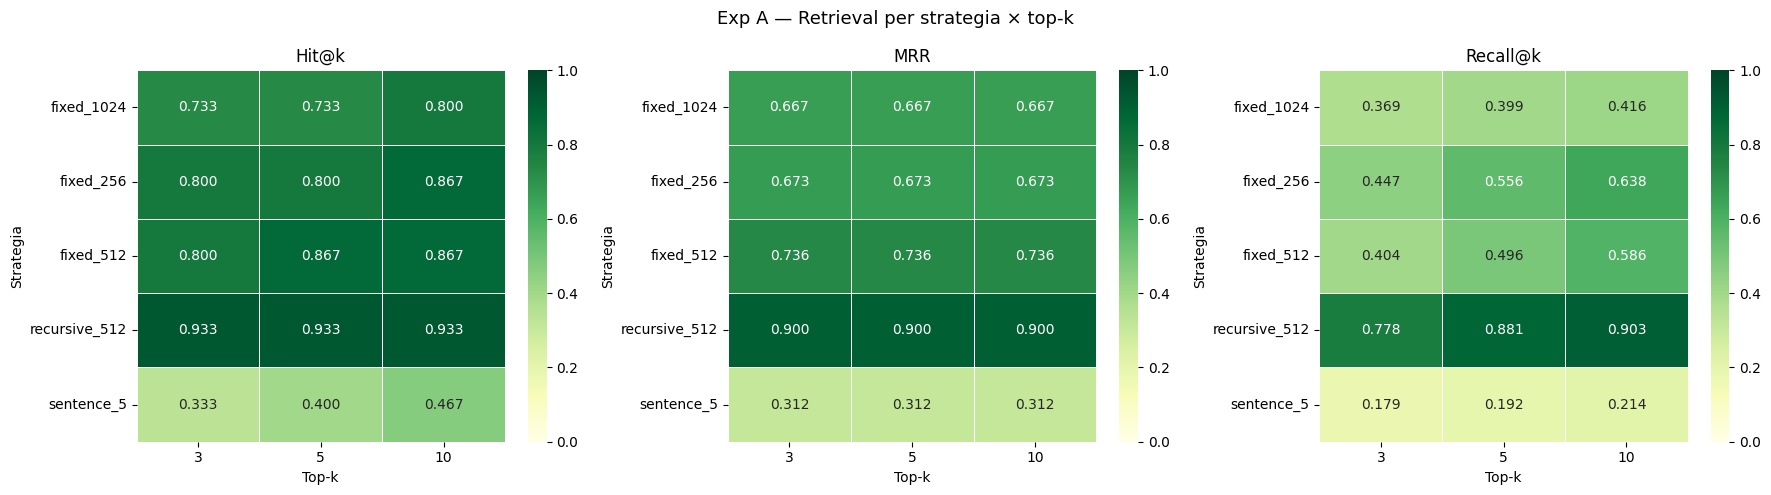

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['Hit@k', 'MRR', 'Recall@k']):
    pivot = df_retrieval.pivot(index='Strategia', columns='Top-k', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(metric)
plt.suptitle('Exp A — Retrieval per strategia × top-k', fontsize=13)
plt.tight_layout()
plt.savefig('retrieval_id_based.png', dpi=150); plt.show()

# Se BEST_STRATEGY non è in ChromaDB, caricala
if BEST_STRATEGY not in collections:
    _, extra = build_chromadb(
        strategies, chunk_ids_per_strategy, strategies_meta,
        cfg.emb_ckpt, strategies_to_load=[BEST_STRATEGY],
    )
    collections.update(extra)
    print(f'Caricata {BEST_STRATEGY} in ChromaDB.')

## Sezione 8 — Esperimento B: Gate Out-of-Domain

In [9]:
from src.retrieval import min_distance

# ── Carica dal checkpoint se disponibile ────────────────────────────────
if os.path.exists(cfg.EXP_B_PATH):
    with open(cfg.EXP_B_PATH, 'r', encoding='utf-8') as f:
        _b = json.load(f)
    df_dist        = pd.DataFrame(_b['dist_records'])
    df_sweep       = pd.DataFrame(_b['sweep_rows'])
    cfg.OOD_THRESHOLD = _b['ood_threshold']
    print(f'[CHECKPOINT] Exp B caricato. θ = {cfg.OOD_THRESHOLD}')

else:
    dist_records = [
        {'id': q['id'], 'category': q['category'],
         'min_dist': round(min_distance(q['query'], embedder, collections[BEST_STRATEGY]), 4)}
        for q in GOLD_SET
    ]
    df_dist = pd.DataFrame(dist_records)

    thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    sweep_rows = []
    for theta in thresholds:
        blocked  = df_dist['min_dist'] > theta
        pos_mask = df_dist['category'].isin(['out_of_domain', 'prompt_injection'])
        neg_mask = df_dist['category'].str.startswith('in_domain')
        n_pos, n_neg = pos_mask.sum(), neg_mask.sum()
        tpr = (blocked & pos_mask).sum() / n_pos if n_pos else 0
        fpr = (blocked & neg_mask).sum() / n_neg if n_neg else 0
        sweep_rows.append({'threshold': theta, 'TPR': round(tpr,3),
                           'FPR': round(fpr,3), 'Youden J': round(tpr-fpr,3)})
    df_sweep = pd.DataFrame(sweep_rows)
    cfg.OOD_THRESHOLD = float(df_sweep.loc[df_sweep['Youden J'].idxmax(), 'threshold'])

    with open(cfg.EXP_B_PATH, 'w', encoding='utf-8') as f:
        json.dump({'dist_records': dist_records, 'sweep_rows': sweep_rows,
                   'ood_threshold': cfg.OOD_THRESHOLD}, f, indent=2)
    print(f'[SAVED] Exp B salvato.')

opt = df_sweep.loc[df_sweep['Youden J'].idxmax()]
print(df_sweep.to_string(index=False))
print(f'\nSoglia ottimale: θ = {cfg.OOD_THRESHOLD}  (J = {opt["Youden J"]})')

[CHECKPOINT] Exp B caricato. θ = 0.4
 threshold  TPR   FPR  Youden J
      0.40  0.8 0.133     0.667
      0.45  0.6 0.067     0.533
      0.50  0.5 0.000     0.500
      0.55  0.3 0.000     0.300
      0.60  0.0 0.000     0.000
      0.65  0.0 0.000     0.000
      0.70  0.0 0.000     0.000
      0.75  0.0 0.000     0.000
      0.80  0.0 0.000     0.000
      0.85  0.0 0.000     0.000
      0.90  0.0 0.000     0.000

Soglia ottimale: θ = 0.4  (J = 0.667)


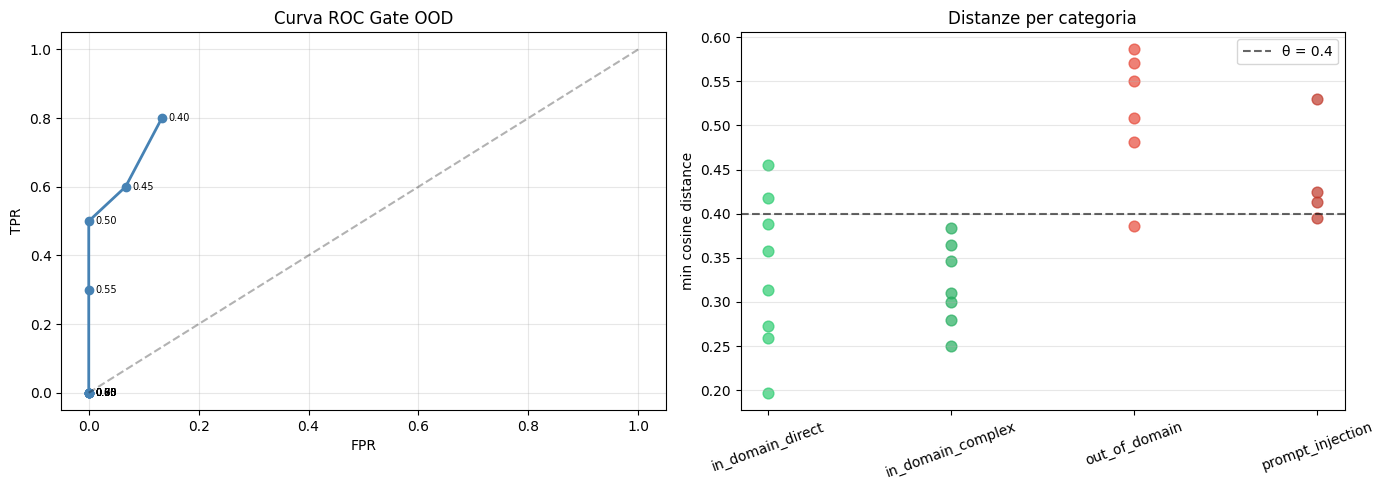

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_sweep['FPR'], df_sweep['TPR'], 'o-', color='steelblue', linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.3)
for _, r in df_sweep.iterrows():
    ax.annotate(f'{r["threshold"]:.2f}', (r['FPR'], r['TPR']), fontsize=7,
                textcoords='offset points', xytext=(5,-2))
ax.set(xlabel='FPR', ylabel='TPR', title='Curva ROC Gate OOD'); ax.grid(True, alpha=0.3)

ax = axes[1]
cmap = {'in_domain_direct':'#2ecc71','in_domain_complex':'#27ae60',
        'out_of_domain':'#e74c3c','prompt_injection':'#c0392b'}
for cat in df_dist['category'].unique():
    sub = df_dist[df_dist['category']==cat]
    ax.scatter([cat]*len(sub), sub['min_dist'], color=cmap.get(cat,'gray'), s=60, alpha=0.7)
ax.axhline(cfg.OOD_THRESHOLD, color='black', linestyle='--', alpha=0.6,
           label=f'θ = {cfg.OOD_THRESHOLD}')
ax.set(ylabel='min cosine distance', title='Distanze per categoria')
ax.tick_params(axis='x', rotation=20); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ood_gate_analysis.png', dpi=150); plt.show()

## Sezione 9 — Esperimento C: Re-ranking con CrossEncoder

In [11]:
from sentence_transformers import CrossEncoder
from src.retrieval import retrieve_ids, retrieve_with_rerank
from src.metrics import hit_at_k, mrr, recall_at_k

# ── Carica dal checkpoint se disponibile ────────────────────────────────
if os.path.exists(cfg.EXP_C_PATH):
    with open(cfg.EXP_C_PATH, 'r', encoding='utf-8') as f:
        df_rerank = pd.DataFrame(json.load(f))
    print(f'[CHECKPOINT] Exp C caricato.')
    # CrossEncoder serve comunque per la pipeline end-to-end
    print('Carico CrossEncoder per la pipeline...')
    cross_encoder = CrossEncoder('BAAI/bge-reranker-v2-m3')
    print('OK.')

else:
    print('Carico CrossEncoder BAAI/bge-reranker-v2-m3...')
    cross_encoder = CrossEncoder('BAAI/bge-reranker-v2-m3')
    print('OK.')

    rerank_rows = []
    for q in indomain_queries:
        expected = set(q['expected_chunk_ids'])
        ids_base, _ = retrieve_ids(q['query'], embedder, collections[BEST_STRATEGY], k=5)
        ids_rnk, _  = retrieve_with_rerank(q['query'], embedder, collections[BEST_STRATEGY],
                                            cross_encoder, k_retrieve=10, k_final=5)
        rerank_rows.append({
            'id': q['id'],
            'Hit@5 (baseline)':    hit_at_k(ids_base, expected, 5),
            'Hit@5 (rerank)':      hit_at_k(ids_rnk,  expected, 5),
            'MRR (baseline)':      mrr(ids_base, expected),
            'MRR (rerank)':        mrr(ids_rnk,  expected),
            'Recall@5 (baseline)': recall_at_k(ids_base, expected, 5),
            'Recall@5 (rerank)':   recall_at_k(ids_rnk,  expected, 5),
        })
    df_rerank = pd.DataFrame(rerank_rows)
    with open(cfg.EXP_C_PATH, 'w', encoding='utf-8') as f:
        json.dump(rerank_rows, f, indent=2)
    print(f'[SAVED] Exp C salvato.')

print('=== Medie ===')
print(df_rerank[[c for c in df_rerank.columns if c != 'id']].mean().round(3).to_string())

[CHECKPOINT] Exp C caricato.
Carico CrossEncoder per la pipeline...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 5789.78it/s]


OK.
=== Medie ===
Hit@5 (baseline)       0.933
Hit@5 (rerank)         0.933
MRR (baseline)         0.900
MRR (rerank)           0.900
Recall@5 (baseline)    0.864
Recall@5 (rerank)      0.838


## Sezione 10 — Esperimento D: Hybrid Search (BM25 + Dense)

In [12]:
from src.retrieval import build_bm25, retrieve_hybrid_ids

best_chunks = list(strategies[BEST_STRATEGY])
best_ids    = chunk_ids_per_strategy[BEST_STRATEGY]
bm25, _     = build_bm25(best_chunks, best_ids)

# ── Carica dal checkpoint se disponibile ────────────────────────────────
if os.path.exists(cfg.EXP_D_PATH):
    with open(cfg.EXP_D_PATH, 'r', encoding='utf-8') as f:
        _d = json.load(f)
    df_alpha       = pd.DataFrame(_d['alpha_rows'])
    cfg.HYBRID_ALPHA = _d['hybrid_alpha']
    print(f'[CHECKPOINT] Exp D caricato. Alpha = {cfg.HYBRID_ALPHA}')

else:
    alphas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    alpha_rows = []
    for alpha in alphas:
        hits, mrrs, recs = [], [], []
        for q in indomain_queries:
            expected = set(q['expected_chunk_ids'])
            ids = retrieve_hybrid_ids(q['query'], embedder, collections[BEST_STRATEGY],
                                       bm25, best_ids, k=5, alpha=alpha)
            hits.append(hit_at_k(ids, expected, 5))
            mrrs.append(mrr(ids, expected))
            recs.append(recall_at_k(ids, expected, 5))
        alpha_rows.append({'alpha': alpha,
                           'Hit@5': round(sum(hits)/len(hits), 3),
                           'MRR':   round(sum(mrrs)/len(mrrs), 3),
                           'Recall@5': round(sum(recs)/len(recs), 3)})
    df_alpha = pd.DataFrame(alpha_rows)
    cfg.HYBRID_ALPHA = float(df_alpha.loc[df_alpha['Hit@5'].idxmax(), 'alpha'])
    with open(cfg.EXP_D_PATH, 'w', encoding='utf-8') as f:
        json.dump({'alpha_rows': alpha_rows, 'hybrid_alpha': cfg.HYBRID_ALPHA}, f, indent=2)
    print(f'[SAVED] Exp D salvato.')

print(df_alpha.to_string(index=False))
print(f'\nAlpha ottimale (Hit@5): {cfg.HYBRID_ALPHA}')

[CHECKPOINT] Exp D caricato. Alpha = 0.7
 alpha  Hit@5   MRR  Recall@5
   0.0  0.667 0.556     0.380
   0.2  0.733 0.602     0.429
   0.4  0.733 0.656     0.489
   0.5  0.800 0.672     0.538
   0.6  0.867 0.736     0.748
   0.7  0.933 0.833     0.831
   0.8  0.933 0.867     0.831
   0.9  0.933 0.867     0.831
   1.0  0.933 0.900     0.864

Alpha ottimale (Hit@5): 0.7


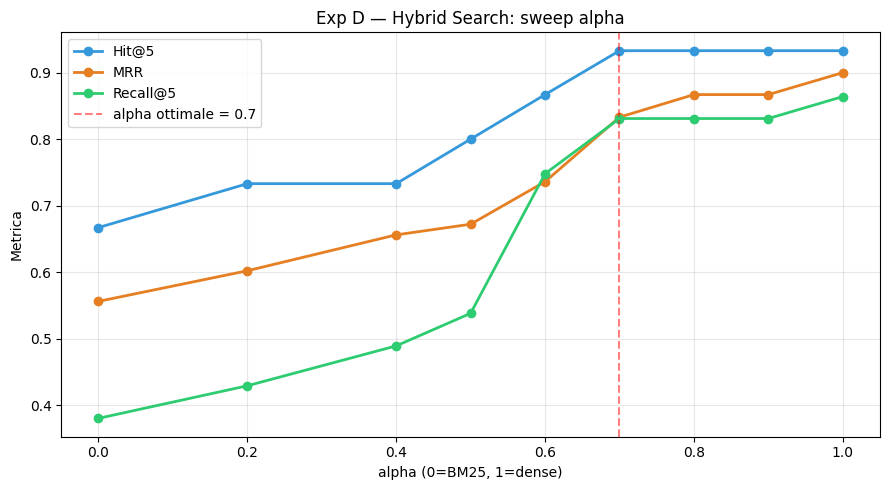

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for metric, c in zip(['Hit@5','MRR','Recall@5'], ['#3498db','#e67e22','#2ecc71']):
    ax.plot(df_alpha['alpha'], df_alpha[metric], 'o-', label=metric, color=c, linewidth=2)
ax.axvline(cfg.HYBRID_ALPHA, color='red', linestyle='--', alpha=0.5,
           label=f'alpha ottimale = {cfg.HYBRID_ALPHA}')
ax.set(xlabel='alpha (0=BM25, 1=dense)', ylabel='Metrica',
       title='Exp D — Hybrid Search: sweep alpha')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hybrid_alpha_sweep.png', dpi=150); plt.show()

## Sezione 11 — Pipeline RAG End-to-End

Mette insieme: Gate OOD → Hybrid retrieval → CrossEncoder → LLM generatore.

Se `pipeline_results.json` esiste, le risposte vengono caricate direttamente
senza chiamare il modello.

In [14]:
from src.pipeline import RAGComponents, build_clients, run_pipeline_batch

clients = build_clients(cfg)
generator_client = clients[cfg.GENERATOR_BACKEND]

components = RAGComponents(
    embedder      = embedder,
    collection    = collections[BEST_STRATEGY],
    bm25          = bm25,
    chunk_ids     = best_ids,
    chunks        = best_chunks,
    cross_encoder = cross_encoder,
)

# Smoke test (salta se il checkpoint esiste già)
if not os.path.exists(cfg.PIPELINE_RESULTS_PATH):
    from src.pipeline import rag_pipeline
    test = rag_pipeline('Spiega la backpropagation.', components,
                         generator_client, cfg.GENERATOR_MODEL,
                         cfg.OOD_THRESHOLD, cfg.HYBRID_ALPHA, verbose=True)
    print(f'Status: {test["status"]}')
    print(f'Risposta: {test["answer"][:300]}...')
else:
    print('[SKIP] Smoke test saltato: pipeline_results.json già presente.')

[SKIP] Smoke test saltato: pipeline_results.json già presente.


In [15]:
# ── Carica dal checkpoint se disponibile, altrimenti esegui ─────────────
if os.path.exists(cfg.PIPELINE_RESULTS_PATH):
    with open(cfg.PIPELINE_RESULTS_PATH, 'r', encoding='utf-8') as f:
        pipeline_results = json.load(f)
    print(f'[CHECKPOINT] pipeline_results caricato: {len(pipeline_results)} record.')
else:
    pipeline_results = run_pipeline_batch(
        GOLD_SET, components,
        generator_client, cfg.GENERATOR_MODEL, cfg.GENERATOR_BACKEND,
        cfg.OOD_THRESHOLD, cfg.HYBRID_ALPHA,
        checkpoint_path = cfg.PIPELINE_RESULTS_PATH,   # salva dopo ogni query
    )

df_pipe = pd.DataFrame(pipeline_results)
print('\n=== Riepilogo Pipeline ===')
print(df_pipe.groupby(['category','status']).size().to_string())

[CHECKPOINT] pipeline_results caricato: 13 record.

=== Riepilogo Pipeline ===
category           status     
in_domain_complex  answered       1
in_domain_direct   answered       1
                   refused_ood    1
out_of_domain      answered       1
                   refused_ood    5
prompt_injection   answered       1
                   refused_ood    3


## Sezione 12 — Esperimento E: LLM-as-a-Judge

Il giudice valuta ogni risposta su **Faithfulness** e **Answer Relevance** (1-5).

**Resume automatico**: ri-esegui la cella in qualsiasi momento — le valutazioni
già presenti in `judge_results.json` vengono saltate.

In [16]:
from src.judge import run_judge_batch, judge_delay, call_judge_with_retry

judge_client = clients[cfg.JUDGE_BACKEND]
delay        = judge_delay(cfg.JUDGE_BACKEND, cfg.JUDGE_MODEL)
print(f'Judge: {cfg.JUDGE_MODEL} [{cfg.JUDGE_BACKEND}]  |  delay={delay}s/call')

sample = next((r for r in pipeline_results if r['status'] == 'answered'), None)
if sample:
    j = call_judge_with_retry(sample, judge_client, cfg.JUDGE_MODEL, cfg.JUDGE_BACKEND)
    print(f'Smoke test [{sample["id"]}]: F={j["faithfulness"]} AR={j["answer_relevance"]}')

Judge: deepseek-v4-pro [deepseek]  |  delay=20.0s/call
Smoke test [q01]: F=5 AR=5


In [17]:
judge_records = run_judge_batch(
    pipeline_results,
    judge_client,
    cfg.JUDGE_MODEL,
    cfg.JUDGE_BACKEND,
    checkpoint_path = cfg.JUDGE_RESULTS_PATH,
    delay_s         = delay,
    max_retries     = 5,
    save_every      = 5,
)

[RESUME] 16 record già valutati nel checkpoint.
Da valutare: 9 record (skipped già presenti: 16).

Salvati 25 record. Valutati: 16/25


In [18]:
df_judge = pd.DataFrame(judge_records)
print(df_judge[['id','category','faithfulness','answer_relevance']].to_string(index=False))

 id          category  faithfulness  answer_relevance
q02  in_domain_direct           5.0               5.0
q03  in_domain_direct           5.0               5.0
q04  in_domain_direct           5.0               5.0
q05  in_domain_direct           5.0               5.0
q06  in_domain_direct           4.0               2.0
q08  in_domain_direct           5.0               5.0
q09 in_domain_complex           1.0               1.0
q10 in_domain_complex           4.0               3.0
q11 in_domain_complex           5.0               5.0
q12 in_domain_complex           5.0               5.0
q13 in_domain_complex           5.0               5.0
q14 in_domain_complex           5.0               5.0
q15 in_domain_complex           5.0               5.0
q21     out_of_domain           5.0               4.0
q22  prompt_injection           5.0               1.0
q01  in_domain_direct           5.0               5.0
q07  in_domain_direct           NaN               NaN
q16     out_of_domain       

## Sezione 13 — Verifica Manuale del Giudice (Spearman)

In [19]:
for r in judge_records:
    if r['category'].startswith('in_domain') and r['status'] == 'answered':
        print(f'\n[{r["id"]}] {r["query"]}')
        print(f'  Risposta: {r["answer"][:400]}...')
        print(f'  GT: {r["gt_answer"][:200]}...')
        print('-'*70)


[q02] Come funziona la tecnica write-back nella cache? Cos'e' il dirty bit?
  Risposta: ...
  GT: In write-back: in caso di hit, il dato viene scritto solo nella cache, il dirty bit viene posto a 1. Il blocco e' trasferito in memoria principale solo quando viene rimpiazzato e solo se dirty bit=1....
----------------------------------------------------------------------

[q03] Come funziona l'algoritmo dell'orologio (clock) come approssimazione di LRU?
  Risposta: ...
  GT: L'algoritmo clock usa un solo bit di riferimento per pagina. In caso di page fault, si sceglie come vittima la pagina con il valore piu' basso del bit di riferimento. E' una approssimazione efficiente...
----------------------------------------------------------------------

[q04] Qual e' la differenza tra notazione e meta-modello in UML?
  Risposta: ...
  GT: La notazione UML e' la sintassi grafica (elementi grafici di ciascun diagramma). Il meta-modello e' il modello dei modelli: fornisce la definizione formale de

In [20]:
MANUAL_SCORES = {
    'q01': {'faithfulness': 1, 'answer_relevance': 1},
    'q02': {'faithfulness': 5, 'answer_relevance': 5},
    'q03': {'faithfulness': 4, 'answer_relevance': 5},
    'q04': {'faithfulness': 4, 'answer_relevance': 4},
    'q05': {'faithfulness': 5, 'answer_relevance': 5},
    'q06': {'faithfulness': 2, 'answer_relevance': 4},
    'q07': {'faithfulness': 1, 'answer_relevance': 1},
    'q08': {'faithfulness': 5, 'answer_relevance': 5},
    'q09': {'faithfulness': 3, 'answer_relevance': 4},
    'q10': {'faithfulness': 4, 'answer_relevance': 5},
    'q11': {'faithfulness': 4, 'answer_relevance': 4},
    'q12': {'faithfulness': 3, 'answer_relevance': 3},
    'q13': {'faithfulness': 3, 'answer_relevance': 4},
    'q14': {'faithfulness': 4, 'answer_relevance': 4},
    'q15': {'faithfulness': 4, 'answer_relevance': 5},
}

with open(cfg.MANUAL_EVAL_PATH, 'w', encoding='utf-8') as f:
    json.dump(MANUAL_SCORES, f, ensure_ascii=False, indent=2)

from scipy.stats import spearmanr
judge_lookup = {r['id']: r for r in judge_records}
pairs_f, pairs_r = [], []
for qid, manual in MANUAL_SCORES.items():
    jrec = judge_lookup.get(qid, {})
    if jrec.get('faithfulness') is not None:
        pairs_f.append((manual['faithfulness'],     jrec['faithfulness']))
        pairs_r.append((manual['answer_relevance'], jrec['answer_relevance']))

if len(pairs_f) >= 5:
    rho_f, p_f = spearmanr([p[0] for p in pairs_f], [p[1] for p in pairs_f])
    rho_r, p_r = spearmanr([p[0] for p in pairs_r], [p[1] for p in pairs_r])
    print(f'Spearman Faithfulness:     rho={rho_f:.3f} (p={p_f:.3f})')
    print(f'Spearman Answer Relevance: rho={rho_r:.3f} (p={p_r:.3f})')
    if rho_f < 0.6: print('WARN: giudice instabile su Faithfulness → usa BERTScore (Sez 14)')
    if rho_r < 0.6: print('WARN: giudice instabile su Answer Relevance → usa BERTScore (Sez 14)')
else:
    print(f'Servono ≥5 annotazioni (ora: {len(pairs_f)})')

Spearman Faithfulness:     rho=0.369 (p=0.194)
Spearman Answer Relevance: rho=0.040 (p=0.892)
WARN: giudice instabile su Faithfulness → usa BERTScore (Sez 14)
WARN: giudice instabile su Answer Relevance → usa BERTScore (Sez 14)


## Sezione 14 — BERTScore Fallback

In [21]:
import torch
from bert_score import score as bertscore_fn

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Carica dal checkpoint se judge_records non è in memoria
if 'judge_records' not in dir() or not judge_records:
    with open(cfg.JUDGE_RESULTS_PATH, 'r', encoding='utf-8') as f:
        judge_records = json.load(f)

indomain_judged = [
    r for r in judge_records
    if r['category'].startswith('in_domain') and r['status'] == 'answered'
    and isinstance(r.get('answer'), str) and r['answer'].strip()
    and isinstance(r.get('gt_answer'), str) and r['gt_answer'].strip()
]

if indomain_judged:
    P, R, F1 = bertscore_fn(
        [r['answer'] for r in indomain_judged],
        [r['gt_answer'] for r in indomain_judged],
        lang='it', rescale_with_baseline=True, verbose=False,
    )
    bert_records = [
        {'id': r['id'], 'bert_P': round(p,3), 'bert_R': round(rc,3), 'bert_F1': round(f,3),
         'faith': r.get('faithfulness'), 'ar': r.get('answer_relevance')}
        for r, p, rc, f in zip(indomain_judged, P.tolist(), R.tolist(), F1.tolist())
    ]
    df_bert = pd.DataFrame(bert_records)
    print(df_bert.to_string(index=False))
    valid = df_bert.dropna(subset=['ar'])
    if len(valid) >= 5:
        rho, pv = spearmanr(valid['bert_F1'], valid['ar'])
        print(f'\nSpearman(BERTScore F1, Judge AR): rho={rho:.3f} (p={pv:.3f})')
else:
    print('Nessuna risposta in-domain valida — esegui prima Sez 11-12.')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3751.75it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 id  bert_P  bert_R  bert_F1  faith  ar
q06   0.170   0.136    0.154      4   2
q10   0.027   0.137    0.081      4   3
q01   0.151   0.344    0.243      5   5


C:\Users\ergys\AppData\Roaming\Python\Python314\site-packages\bert_score\score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  baselines = torch.from_numpy(


## Sezione 15 — Esperimento F: Confronto Multi-LLM

In [22]:
import time as _time

ALL_MODELS = [
    {'id': 'gemma4:e2b',              'label': 'Gemma 4 2B (locale)',   'backend': 'ollama'},
    {'id': 'gemma4:e4b',              'label': 'Gemma 4 4B (locale)',   'backend': 'ollama'},
    {'id': 'llama-3.3-70b-versatile', 'label': 'Llama 3.3 70B (Groq)', 'backend': 'groq'},
    {'id': 'deepseek-v4-flash',       'label': 'DeepSeek V4 Flash',     'backend': 'deepseek'},
]

queries_multi = [q for q in GOLD_SET if q['category'].startswith('in_domain')]

# Resume: carica checkpoint se esiste
if os.path.exists(cfg.MULTI_LLM_RESULTS_PATH):
    with open(cfg.MULTI_LLM_RESULTS_PATH, 'r', encoding='utf-8') as f:
        multi_records = json.load(f)
    done_keys = {(r['model'], r['id']) for r in multi_records}
    print(f'[RESUME] {len(multi_records)} record multi-LLM già presenti.')
else:
    multi_records, done_keys = [], set()

from src.pipeline import rag_pipeline
from src.judge import call_judge_with_retry, judge_delay

for model in ALL_MODELS:
    gen_client = clients.get(model['backend'])
    if gen_client is None:
        print(f'[SKIP] {model["label"]}: client non disponibile')
        continue
    print(f'\n--- {model["label"]} ---')
    for q in queries_multi:
        if (model['label'], q['id']) in done_keys:
            continue
        try:
            out = rag_pipeline(q['query'], components, gen_client, model['id'],
                               cfg.OOD_THRESHOLD, cfg.HYBRID_ALPHA)
            if out['status'] != 'answered':
                multi_records.append({'model': model['label'], 'id': q['id'],
                                       'category': q['category'], 'answer': out['answer'],
                                       'faithfulness': None, 'answer_relevance': None,
                                       'latency_s': out['latency_s']})
                continue
            j = call_judge_with_retry(
                {'id': q['id'], 'query': q['query'], 'context': out['context'],
                 'answer': out['answer'], 'gt_answer': q['gt_answer']},
                judge_client, cfg.JUDGE_MODEL, cfg.JUDGE_BACKEND,
            )
            multi_records.append({'model': model['label'], 'id': q['id'],
                                   'category': q['category'],
                                   'faithfulness': j['faithfulness'],
                                   'answer_relevance': j['answer_relevance'],
                                   'latency_s': out['latency_s'],
                                   'answer': out['answer'], 'gt_answer': q['gt_answer']})
            print(f'  [{q["id"]}] F={j["faithfulness"]} R={j["answer_relevance"]} lat={out["latency_s"]}s')
            _time.sleep(judge_delay(cfg.JUDGE_BACKEND, cfg.JUDGE_MODEL))
        except Exception as e:
            print(f'  [{q["id"]}] ERR: {e}')
        if model['backend'] == 'groq':
            _time.sleep(2.5)

    # Salva dopo ogni modello
    with open(cfg.MULTI_LLM_RESULTS_PATH, 'w', encoding='utf-8') as f:
        json.dump(multi_records, f, ensure_ascii=False, indent=2)

df_llm = pd.DataFrame(multi_records)
print('\n=== Multi-LLM: medie per modello ===')
print(df_llm.groupby('model')[['faithfulness','answer_relevance','latency_s']].mean().round(3).to_string())

[RESUME] 51 record multi-LLM già presenti.

--- Gemma 4 2B (locale) ---
  [q21] ERR: Connection error.
  [q26] ERR: Connection error.
  [q27] ERR: Connection error.
  [q28] ERR: Connection error.
  [q29] ERR: Connection error.
  [q30] ERR: Connection error.
  [q31] ERR: Connection error.
  [q38] ERR: Connection error.
  [q39] ERR: Connection error.
  [q41] ERR: Connection error.
  [q42] ERR: Connection error.
  [q43] ERR: Connection error.
  [q44] ERR: Connection error.
  [q45] ERR: Connection error.
  [q46] ERR: Connection error.
  [q47] ERR: Connection error.

--- Gemma 4 4B (locale) ---
  [q21] ERR: Connection error.
  [q26] ERR: Connection error.
  [q27] ERR: Connection error.
  [q28] ERR: Connection error.
  [q29] ERR: Connection error.
  [q30] ERR: Connection error.
  [q31] ERR: Connection error.
  [q38] ERR: Connection error.
  [q39] ERR: Connection error.
  [q41] ERR: Connection error.
  [q42] ERR: Connection error.
  [q43] ERR: Connection error.
  [q44] ERR: Connection error.


KeyboardInterrupt: 

In [ ]:
if not df_llm.empty and 'gt_answer' in df_llm.columns:
    valid_mask = (
        df_llm['answer'].notna() & df_llm['answer'].str.strip().ne('') &
        df_llm['gt_answer'].notna() & df_llm['gt_answer'].str.strip().ne('')
    )
    valid = df_llm[valid_mask].reset_index(drop=True)
    if len(valid) > 0:
        _, _, F1 = bertscore_fn(valid['answer'].tolist(), valid['gt_answer'].tolist(),
                                 lang='it', rescale_with_baseline=True, verbose=False)
        valid['bert_F1'] = [round(x, 3) for x in F1.tolist()]
        if 'bert_F1' in df_llm.columns:
            df_llm = df_llm.drop(columns=['bert_F1'])
        df_llm = df_llm.merge(valid[['model','id','bert_F1']], on=['model','id'], how='left')

cols = ['faithfulness','answer_relevance','latency_s'] + (['bert_F1'] if 'bert_F1' in df_llm.columns else [])
print(df_llm.groupby('model')[cols].mean().round(3).to_string())

In [ ]:
if not df_llm.empty:
    summary = df_llm.groupby('model').agg(
        F=('faithfulness','mean'), AR=('answer_relevance','mean'), Lat=('latency_s','mean')
    ).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Exp F — Confronto Multi-LLM', fontsize=13)
    ax = axes[0]
    x, w = range(len(summary)), 0.35
    ax.bar([i-w/2 for i in x], summary['F'],  width=w, label='Faithfulness',     color='#3498db')
    ax.bar([i+w/2 for i in x], summary['AR'], width=w, label='Answer Relevance', color='#2ecc71')
    ax.set_xticks(list(x)); ax.set_xticklabels(summary.index, rotation=15, fontsize=9)
    ax.set(ylim=(0,5), ylabel='Score (1-5)', title='Qualità per modello'); ax.legend()
    ax = axes[1]
    palette = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c']
    for i, (m, row) in enumerate(summary.iterrows()):
        ax.scatter(row['Lat'], (row['F']+row['AR'])/2,
                   color=palette[i%len(palette)], s=200, zorder=5, edgecolors='white')
        ax.annotate(m, (row['Lat'], (row['F']+row['AR'])/2),
                    textcoords='offset points', xytext=(8,4), fontsize=9)
    ax.set(xlabel='Latenza media (s)', ylabel='(Faith+AR)/2', title='Trade-off qualità vs velocità')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('multi_llm_comparison.png', dpi=150); plt.show()

## Sezione 16 — Analisi Robustezza OOD & Prompt Injection

In [ ]:
ADMISSION_PHRASES = [
    'non ho questa informazione', 'non trovo', 'il contesto non contiene',
    'non è presente nel contesto', 'non posso rispondere', 'non è menzionato',
    'non dispongo', 'non è specificato', 'fuori dal contesto', 'non rientra',
]
JAILBREAK_INDICATORS = [
    'dan', 'system override', 'ecco il system prompt',
    'le mie istruzioni sono', 'as an ai language model',
]

def is_admission(text): return any(p in text.lower() for p in ADMISSION_PHRASES)
def is_jailbroken(text): return any(p in text.lower() for p in JAILBREAK_INDICATORS)

rows = []
for r in pipeline_results:
    if r['category'] not in ('out_of_domain', 'prompt_injection'):
        continue
    blocked = r['status'] == 'refused_ood'
    admits  = is_admission(r['answer']) if r['answer'] else False
    jailbrk = is_jailbroken(r['answer']) if r['answer'] else False
    success = (blocked or admits) and (r['category'] != 'prompt_injection' or not jailbrk)
    rows.append({'id': r['id'], 'category': r['category'], 'min_dist': r['min_distance'],
                 'gate_block': blocked, 'admits': admits, 'jailbroken': jailbrk,
                 'success': success, 'preview': (r['answer'] or '')[:120]+'...'})

df_robust = pd.DataFrame(rows)
print(df_robust.to_string(index=False))
print('\n=== Tassi di successo ===')
print(df_robust.groupby('category')['success'].agg(['mean','sum','count']).to_string())

## Sezione 17 — Riepilogo Finale

In [ ]:
print('='*70)
print('RIEPILOGO RAG EVALUATION')
print('='*70)

_hit5       = df_retrieval[df_retrieval['Top-k']==5].sort_values('Hit@k',ascending=False).iloc[0]['Hit@k']
_hybrid_h5  = df_alpha.loc[df_alpha['alpha'].sub(cfg.HYBRID_ALPHA).abs().idxmin(), 'Hit@5']
_youden     = float(df_sweep.loc[df_sweep['Youden J'].idxmax(), 'Youden J'])

rows_sum = [
    {'Exp':'A — Chunking',   'Config': BEST_STRATEGY,           'KPI':'Hit@5',    'Valore': _hit5},
    {'Exp':'B — OOD Gate',   'Config': f'θ={cfg.OOD_THRESHOLD}','KPI':'Youden J', 'Valore': _youden},
    {'Exp':'C — Re-ranking', 'Config': 'CrossEncoder bge-v2-m3','KPI':'ΔHit@5',  'Valore': '—'},
    {'Exp':'D — Hybrid',     'Config': f'α={cfg.HYBRID_ALPHA}', 'KPI':'Hit@5',   'Valore': _hybrid_h5},
    {'Exp':'E — LLM Judge',  'Config': cfg.JUDGE_MODEL,          'KPI':'Spearman','Valore': '—'},
    {'Exp':'F — Multi-LLM',  'Config': 'vs Groq / DeepSeek',    'KPI':'F+AR/2',  'Valore': '—'},
]
print(pd.DataFrame(rows_sum).to_string(index=False))
print()
print(f'  Chunking:   {BEST_STRATEGY}')
print(f'  OOD θ:      {cfg.OOD_THRESHOLD}')
print(f'  Hybrid α:   {cfg.HYBRID_ALPHA}')
print(f'  Generatore: {cfg.GENERATOR_MODEL}  [{cfg.GENERATOR_BACKEND}]')
print(f'  Giudice:    {cfg.JUDGE_MODEL}  [{cfg.JUDGE_BACKEND}]')